# Explore here

In [1]:
import pandas as pd
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2545&path=sales.csv"
df = pd.read_csv(url)

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.dtypes)


(366, 2)
['date', 'sales']
                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633
date         str
sales    float64
dtype: object


date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64
Tensor shape: (366, 1)


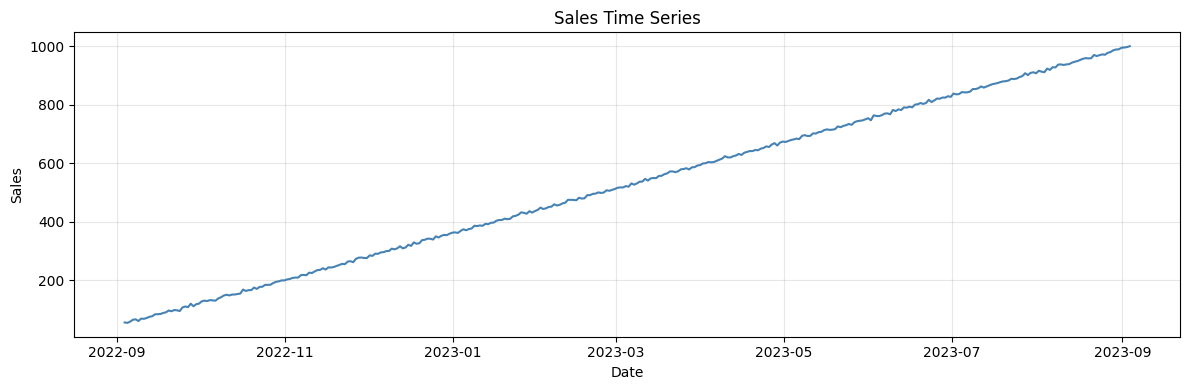

In [3]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

series = df['sales']
tensor = df[['sales']].to_numpy()

print(series.head())
print('Tensor shape:', tensor.shape)

plt.figure(figsize=(12, 4))
plt.plot(series.index, series.values, color='steelblue')
plt.title('Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The trend is clearly upward and approximately linear: sales increase steadily over time with only small random fluctuations.

No obvious stationarity because the mean changes over time due to stong upward trend

Yes, but it is small. The series has minor point-to-point noise around a very strong upward linear trend, so the variability is low relative to the overall increase.

In [4]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

best_order = None
best_aic = float('inf')
best_model = None

for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted
            except Exception:
                continue

print('Best ARIMA order:', best_order)
print('Best AIC:', best_aic)

predictions = best_model.forecast(steps=len(test))


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fre

Best ARIMA order: (1, 1, 3)
Best AIC: 1489.1564735000686


MAE: 2.2954984637055005
RMSE: 2.8457213370761423


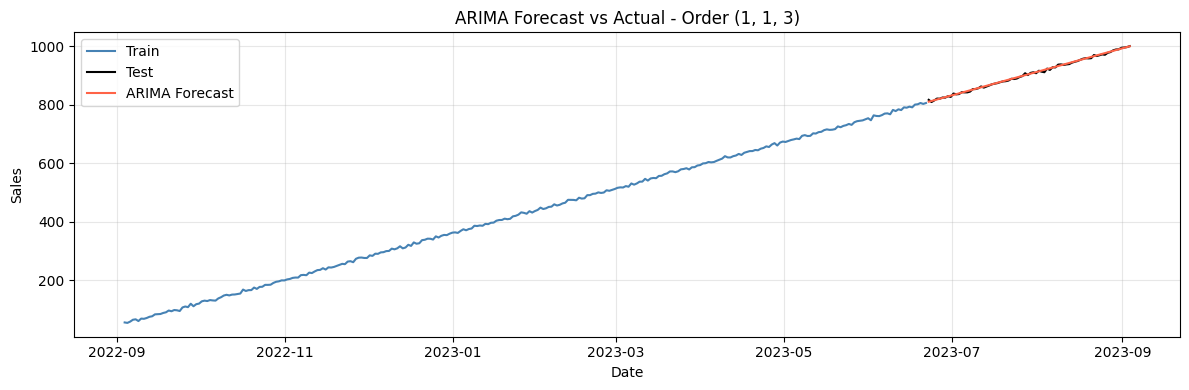

In [6]:
import matplotlib.pyplot as plt
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print('MAE:', mae)
print('RMSE:', rmse)

plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label='Train', color='steelblue')
plt.plot(test.index, test, label='Test', color='black')
plt.plot(test.index, predictions, label='ARIMA Forecast', color='tomato')
plt.title(f'ARIMA Forecast vs Actual - Order {best_order}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MAE is about 2.30 and RMSE is about 2.85.